# Pipeline de Análise e Projeção de Preços da Cesta Básica no Brasil (2020–2030)

**TCC — Engenharia de Software**

Este notebook integra todo o pipeline de ETL, análise exploratória, modelagem preditiva (SARIMA e Prophet) e projeções de cenários para o custo da cesta básica nas 27 capitais brasileiras, com **ênfase na média nacional agregada**.

> **Objetivo:** Gerar visualizações de alta qualidade para apresentação em slides, demonstrando a evolução histórica e projeções até 2030.

## 1. 📦 Importações e Configuração

Nesta seção configuramos o ambiente, importamos os módulos do pipeline e definimos os caminhos de saída. Todos os gráficos serão salvos automaticamente em `outputs/graficos/` para uso nos slides da apresentação.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Adicionar src ao path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))

from extract import load_data
from transform import transformar, calcular_media_nacional, obter_serie_agregada
from load import executar_pipeline, salvar_csv
from eda import executar_eda
from model import executar_modelagem, avaliar_modelos

plt.style.use("seaborn-v0_8-whitegrid")

OUTPUT_GRAFICOS = PROJECT_ROOT / "outputs" / "graficos"
OUTPUT_GRAFICOS.mkdir(parents=True, exist_ok=True)

print(f"Projeto: {PROJECT_ROOT}")
print(f"Gráficos serão salvos em: {OUTPUT_GRAFICOS}")

Projeto: D:\projetos start\Projeto_tcc\cesta-basica-pipeline
Gráficos serão salvos em: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\outputs\graficos


## 2. 🔄 ETL — Extração e Transformação dos Dados

O pipeline começa pela **extração** dos dados via `extract.py`. Por padrão, utilizamos dados **simulados** baseados em valores reais do DIEESE. Para trocar por dados reais, basta editar a função `load_data()` em `src/extract.py`.

Em seguida, aplicamos transformações: interpolação de ausentes, cálculo de variações, identificação de outliers e criação de features para modelagem.

In [2]:
# Executar pipeline ETL completo
df = executar_pipeline()

print(f"\nShape dos dados: {df.shape}")
print(f"Período: {df['data'].min().strftime('%b/%Y')} a {df['data'].max().strftime('%b/%Y')}")
print(f"Capitais: {df['capital'].nunique()}")
df.head(10)

Dados salvos em: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\data\processed\cesta_basica_processada.csv
Banco SQLite: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\data\processed\cesta_basica.db
Registros processados: 2024

Shape dos dados: (2024, 13)
Período: Jan/2020 a Mar/2026
Capitais: 27


,data,capital,estado,regiao,custo,fonte_dado,variacao_mensal_pct,variacao_anual_pct,outlier,lag_1,lag_12,rolling_mean_3,rolling_mean_6
0,2020-01-01,Aracaju,SE,Nordeste,368.69,real_dieese,NaN,NaN,False,NaN,NaN,368.690000,368.690000
1,2020-02-01,Aracaju,SE,Nordeste,371.22,real_dieese,0.686213,NaN,False,368.69,NaN,369.955000,369.955000
2,2020-03-01,Aracaju,SE,Nordeste,390.20,real_dieese,5.112871,NaN,False,371.22,NaN,376.703333,376.703333
3,2020-04-01,Aracaju,SE,Nordeste,401.37,real_dieese,2.862635,NaN,False,390.20,NaN,387.596667,382.870000
4,2020-05-01,Aracaju,SE,Nordeste,400.15,real_dieese,-0.303959,NaN,False,401.37,NaN,397.240000,386.326000
5,2020-06-01,Aracaju,SE,Nordeste,420.03,real_dieese,4.968137,NaN,False,400.15,NaN,407.183333,391.943333
6,2020-07-01,Aracaju,SE,Nordeste,392.75,real_dieese,-6.494774,NaN,False,420.03,NaN,404.310000,395.953333
7,2020-08-01,Aracaju,SE,Nordeste,398.47,real_dieese,1.456397,NaN,False,392.75,NaN,403.750000,400.495000
8,2020-09-01,Aracaju,SE,Nordeste,427.11,real_dieese,7.187492,NaN,False,398.47,NaN,406.110000,406.646667
9,2020-10-01,Aracaju,SE,Nordeste,442.26,real_dieese,3.547096,NaN,False,427.11,NaN,422.613333,413.461667


In [3]:
# Visão geral dos dados transformados
print("Estatísticas do custo (R$):")
df.groupby('capital')['custo'].agg(['mean', 'min', 'max']).round(2).head(10)

Estatísticas do custo (R$):


,mean,min,max
capital,,,
Aracaju,510.88,368.69,598.45
Belo Horizonte,645.68,456.35,784.32
Belém,603.82,415.56,726.38
Boa Vista,641.97,547.90,726.90
Brasília,661.29,441.09,782.65
Campo Grande,677.69,445.40,805.93
Cuiabá,715.62,586.42,838.40
Curitiba,667.50,447.91,793.72
Florianópolis,724.55,489.13,867.83


In [4]:
# Média nacional — início e último mês disponível na série
media = calcular_media_nacional(df).sort_values('data')

inicio = media.iloc[0]
fim = media.iloc[-1]

print(f"Média nacional — {inicio['data'].strftime('%b/%Y')}: R$ {inicio['media_nacional']:,.2f}")
print(f"Média nacional — {fim['data'].strftime('%b/%Y')}: R$ {fim['media_nacional']:,.2f}")

print(f"Variação acumulada: {((fim['media_nacional'] / inicio['media_nacional']) - 1) * 100:.1f}%")


Média nacional — Jan/2020: R$ 475.30
Média nacional — Mar/2026: R$ 721.46
Variação acumulada: 51.8%


## 3. 📊 EDA — Análise Exploratória de Dados

A análise exploratória revela padrões temporais, sazonalidade e diferenças regionais no custo da cesta básica. Todos os gráficos são exportados em PNG (150 dpi) para os slides.

### 3.1 Visão Nacional

O gráfico de evolução histórica mostra todas as 27 capitais, destacando **São Paulo** (vermelho) e a **média nacional** (azul). Observa-se a tendência de alta contínua, acelerada pelo choque da COVID-19 em 2020.

Gráfico salvo: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\outputs\graficos\01_evolucao_historica_nacional.png
Gráfico salvo: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\outputs\graficos\02_heatmap_capitais.png
Gráfico salvo: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\outputs\graficos\03_decomposicao_media_nacional.png
Gráfico salvo: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\outputs\graficos\04_boxplot_regional.png
Gráfico salvo: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\outputs\graficos\05_ranking_capitais_marco2026.png

EDA concluída: 5 gráficos gerados.

--- evolucao ---


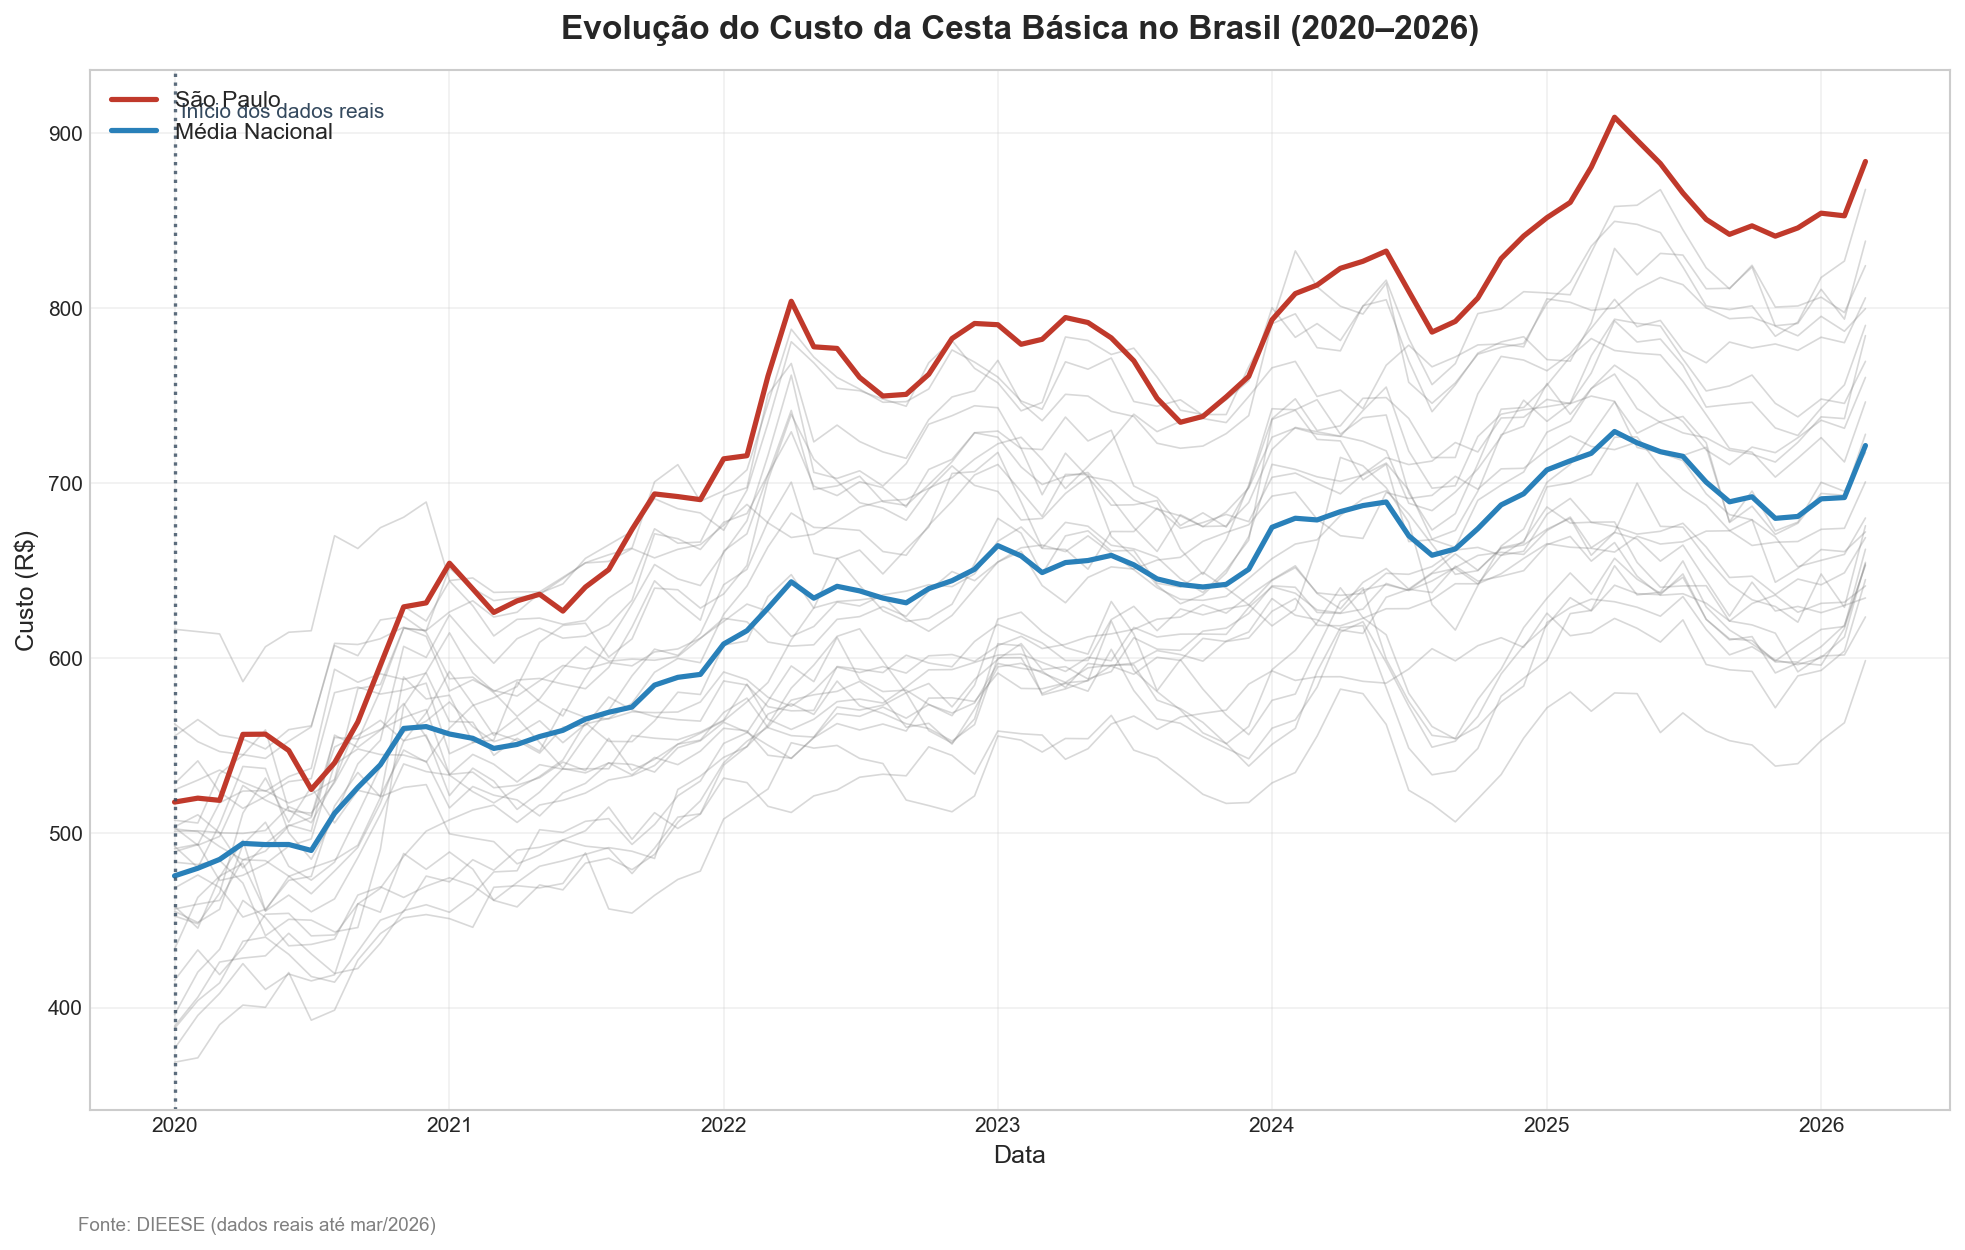


--- heatmap ---


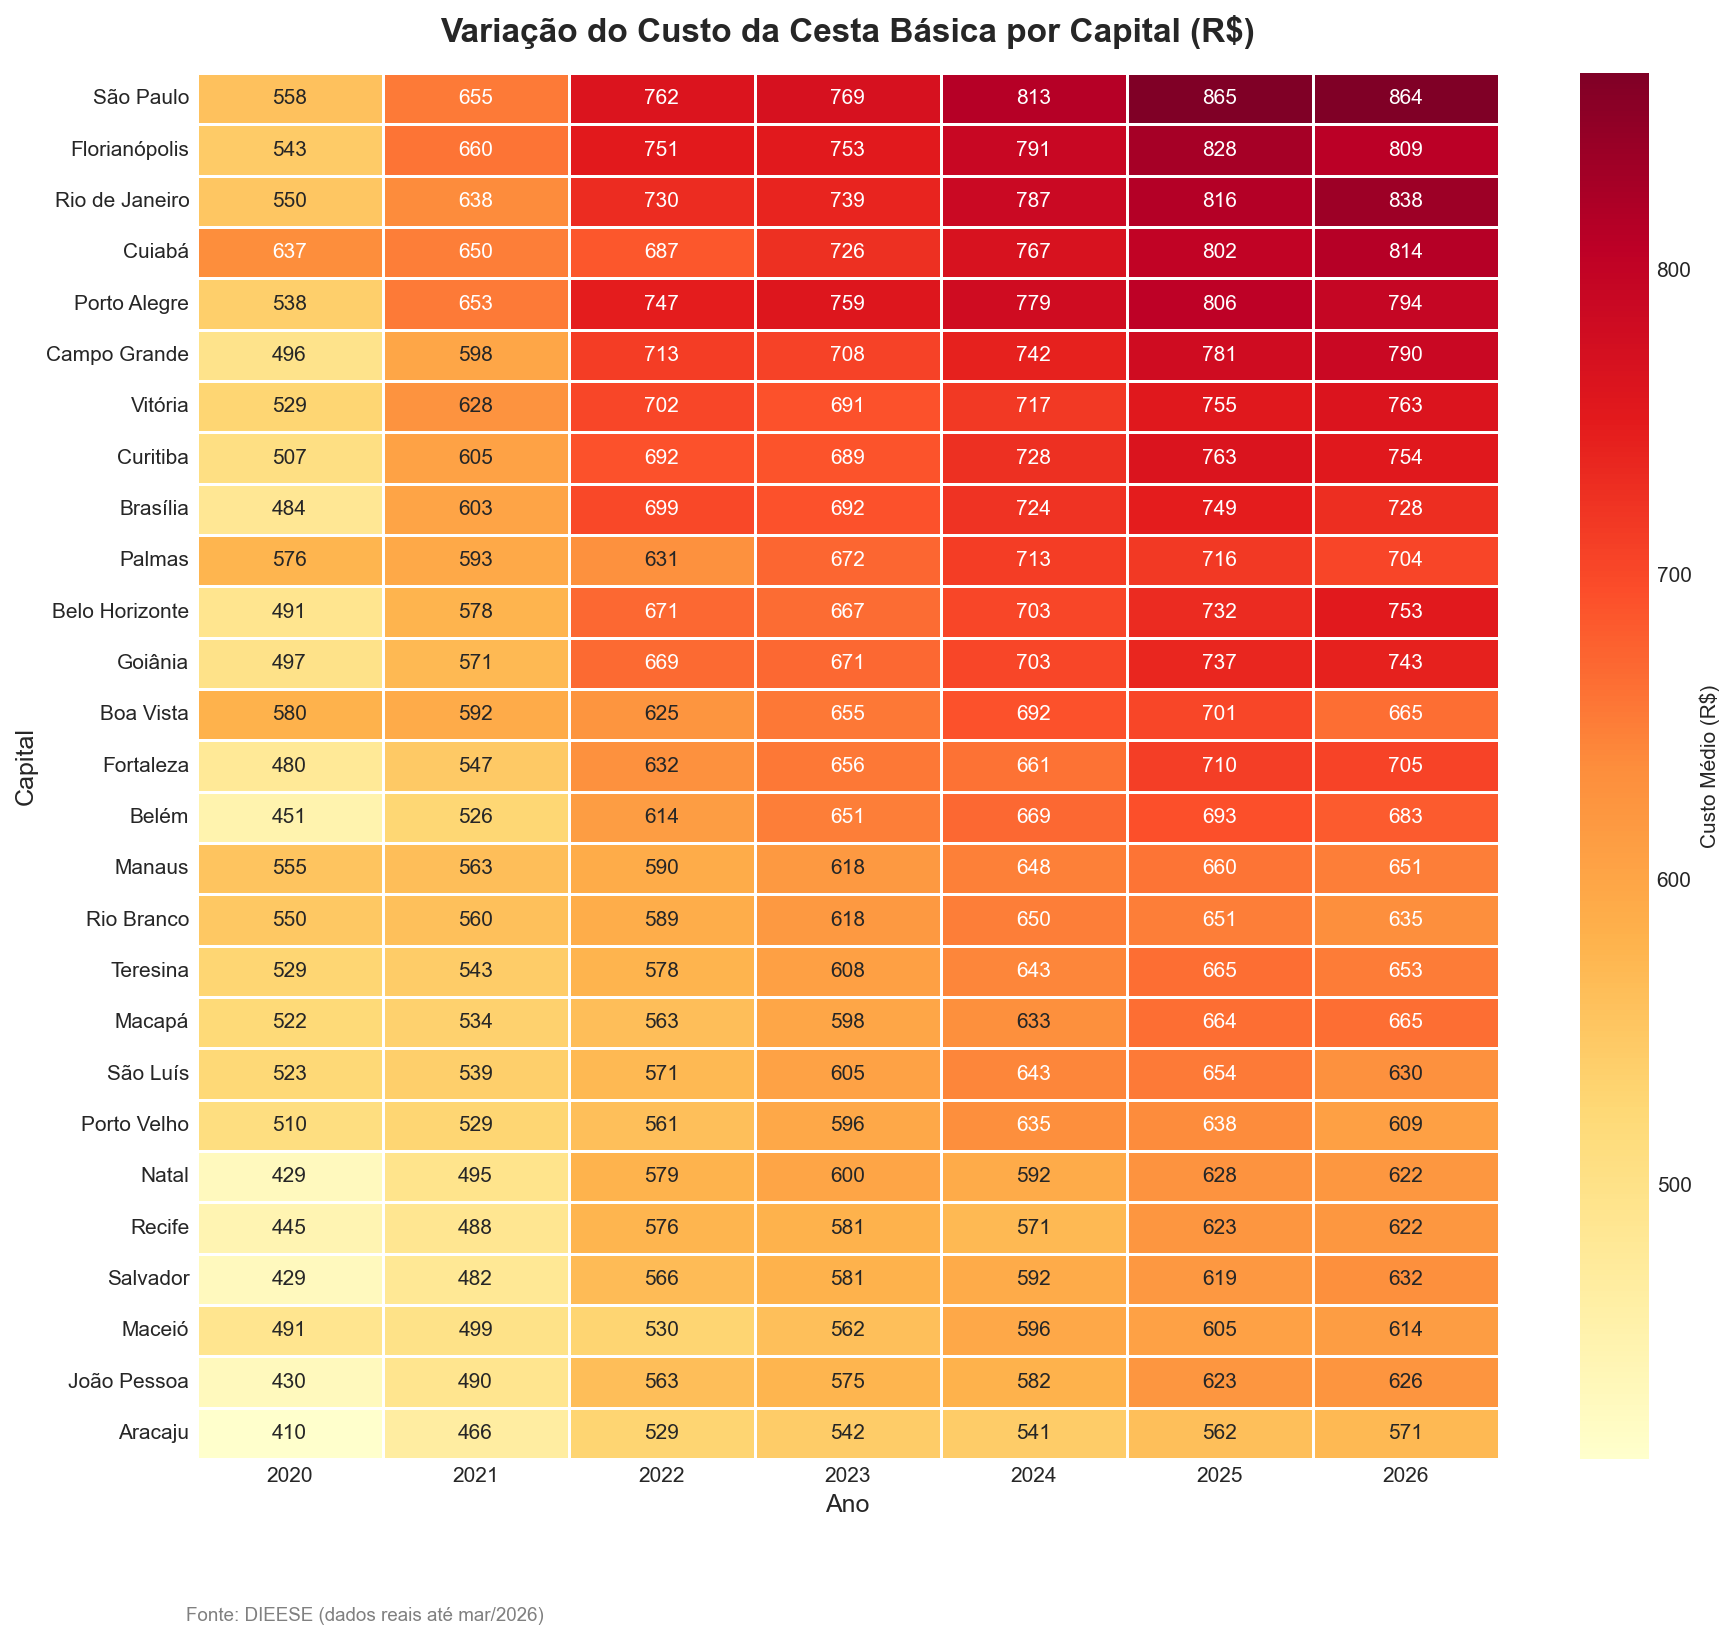


--- decomposicao ---


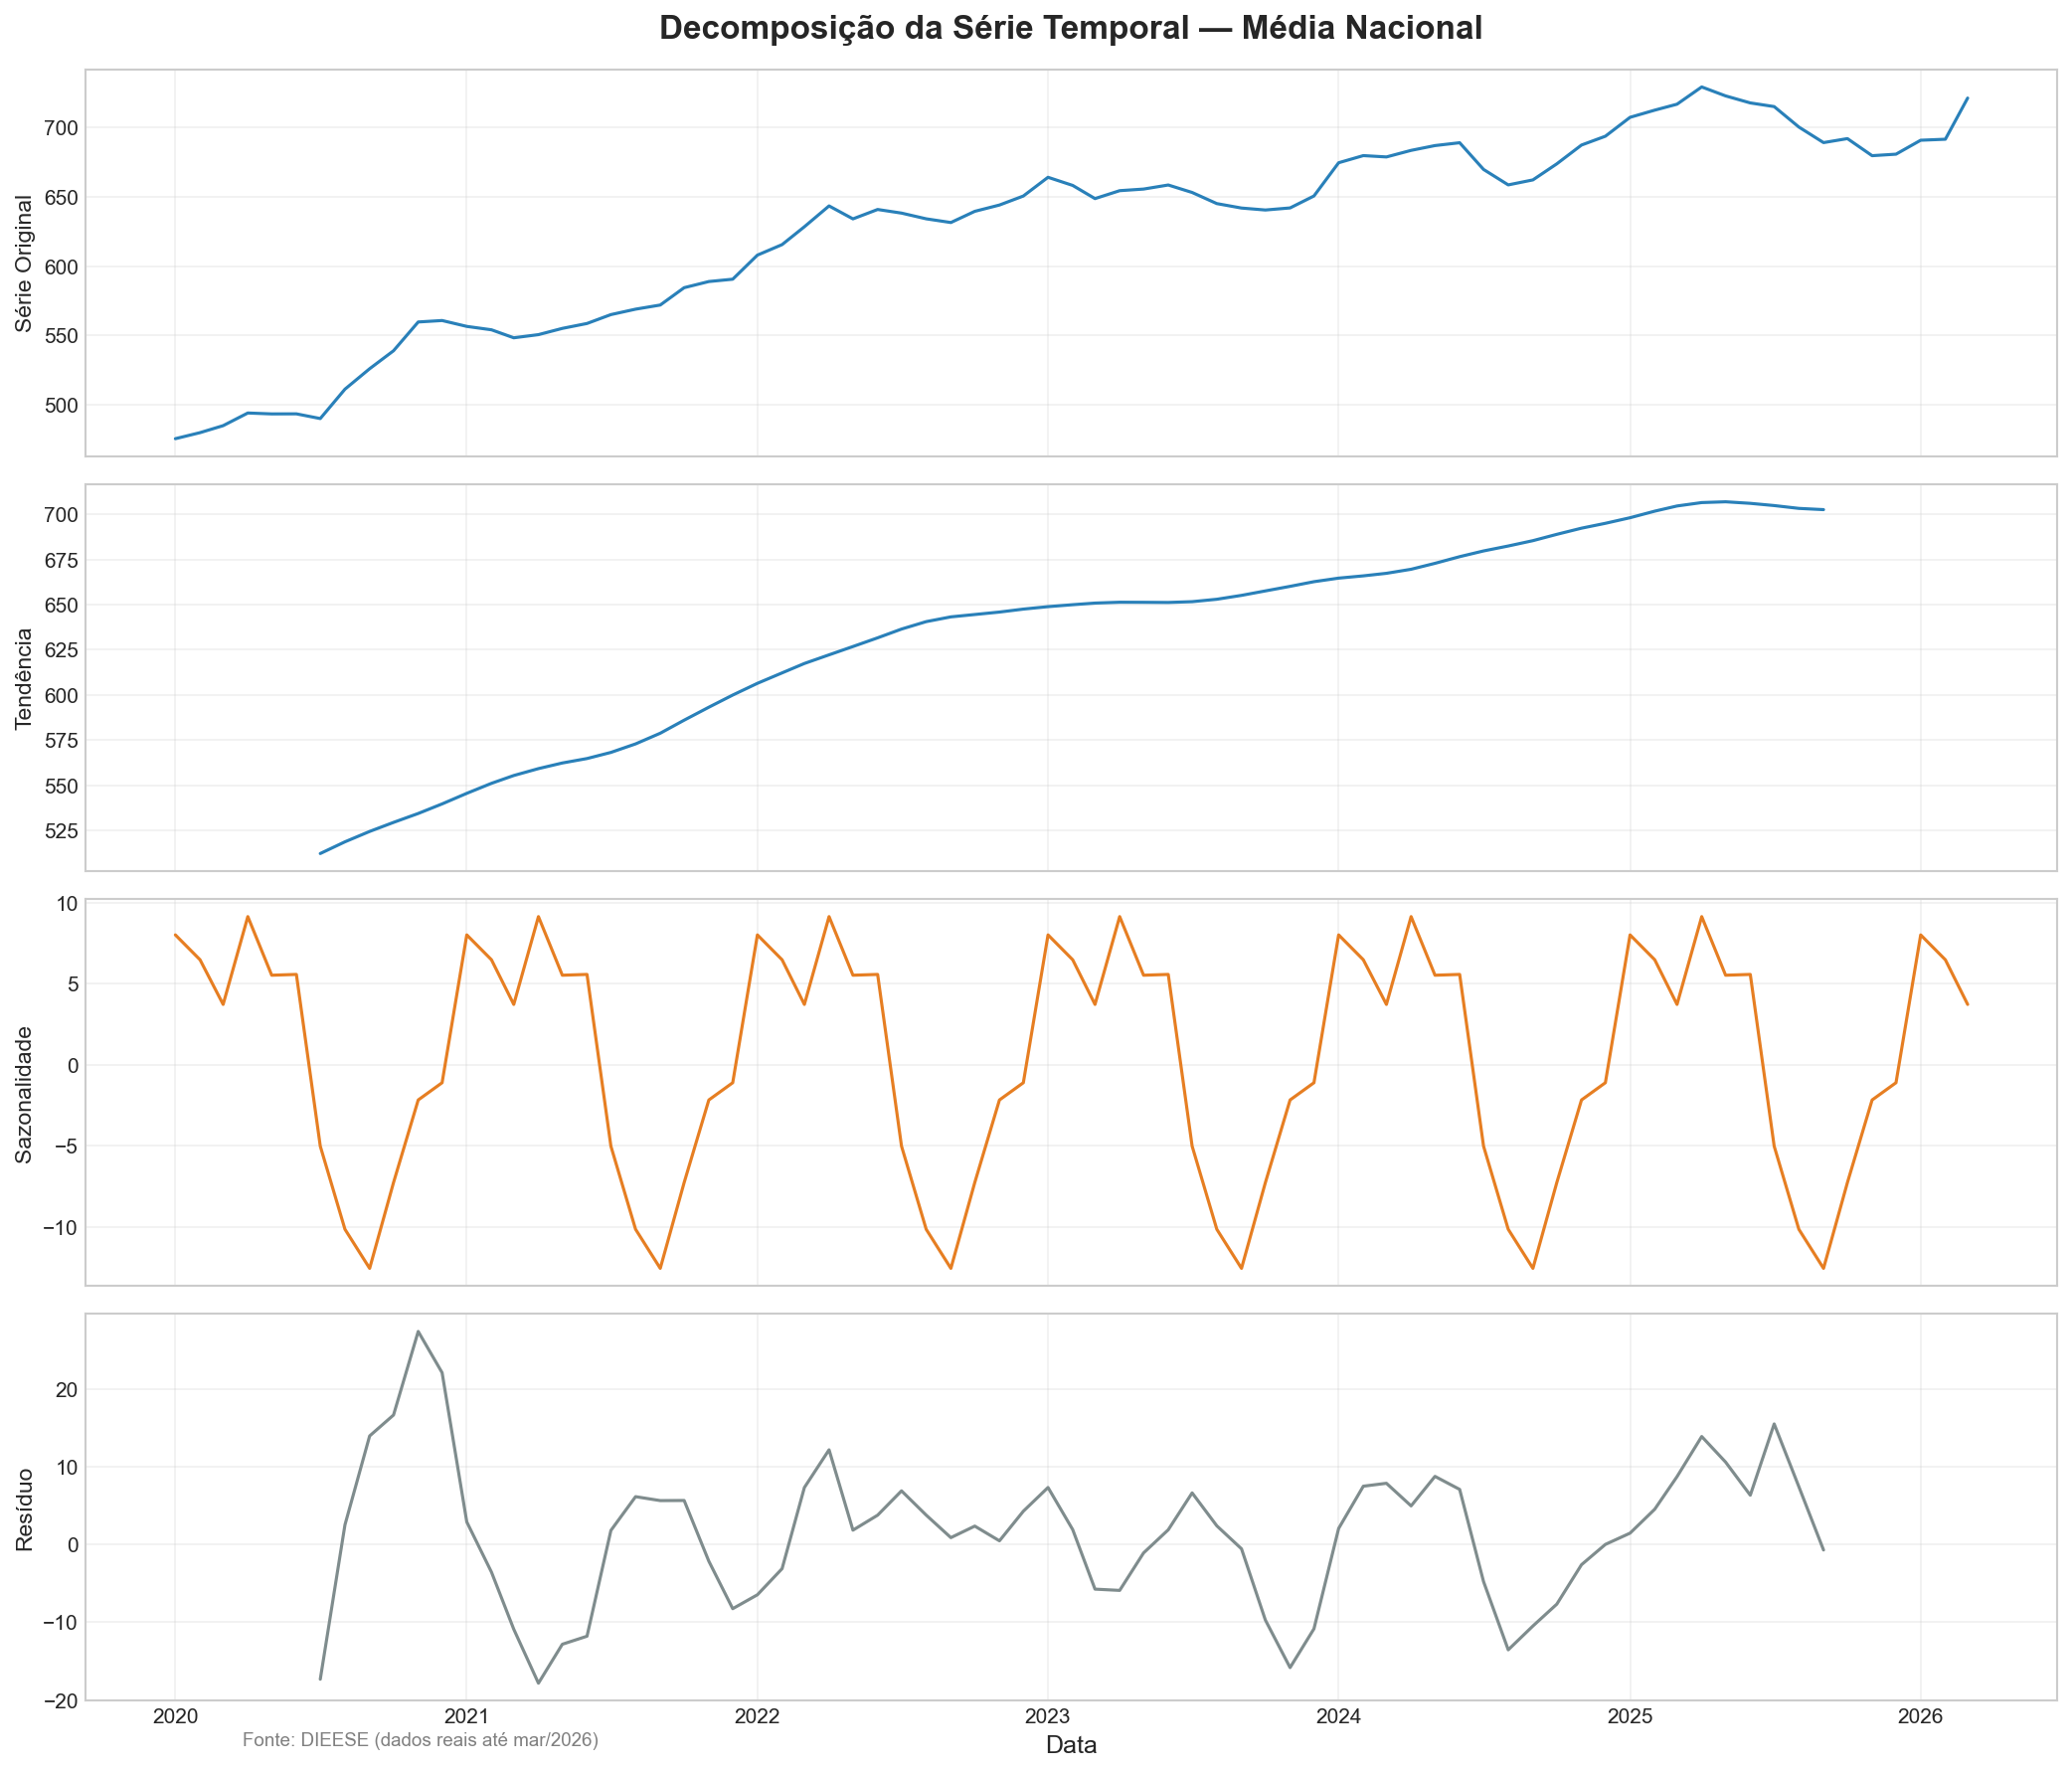


--- boxplot ---


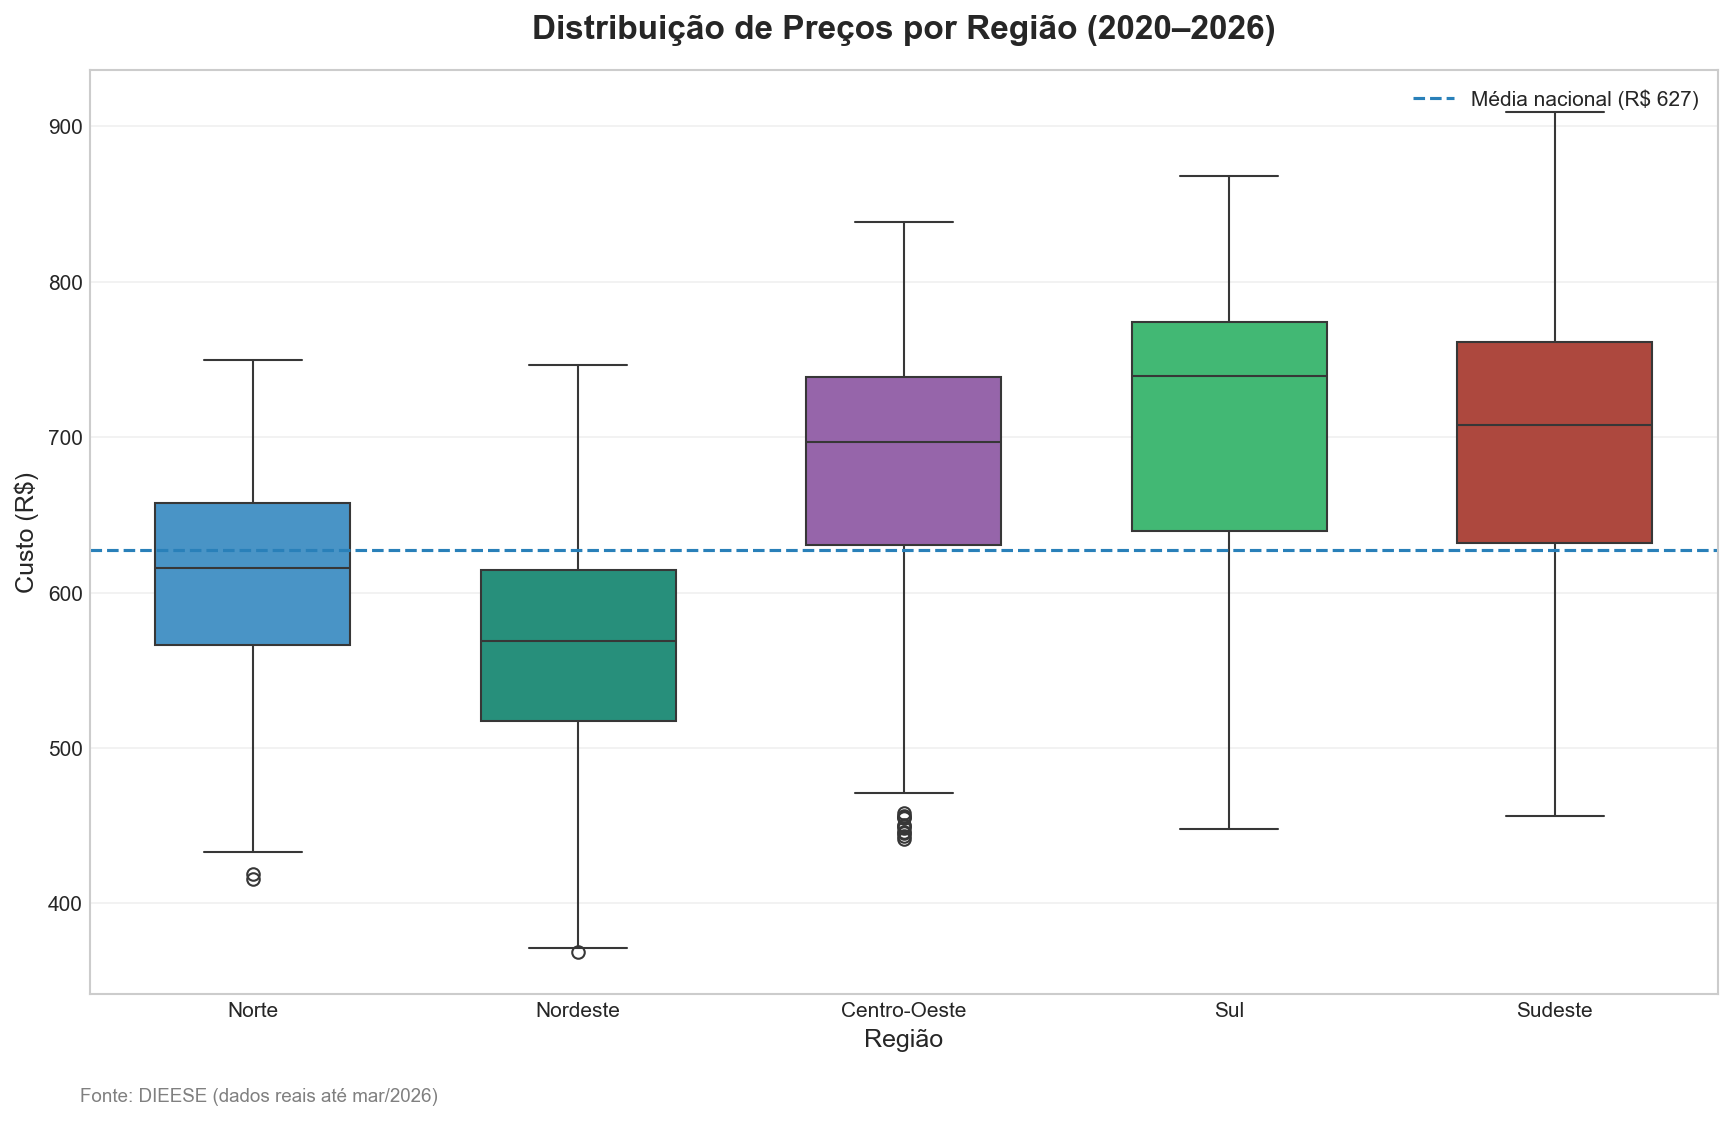


--- ranking ---


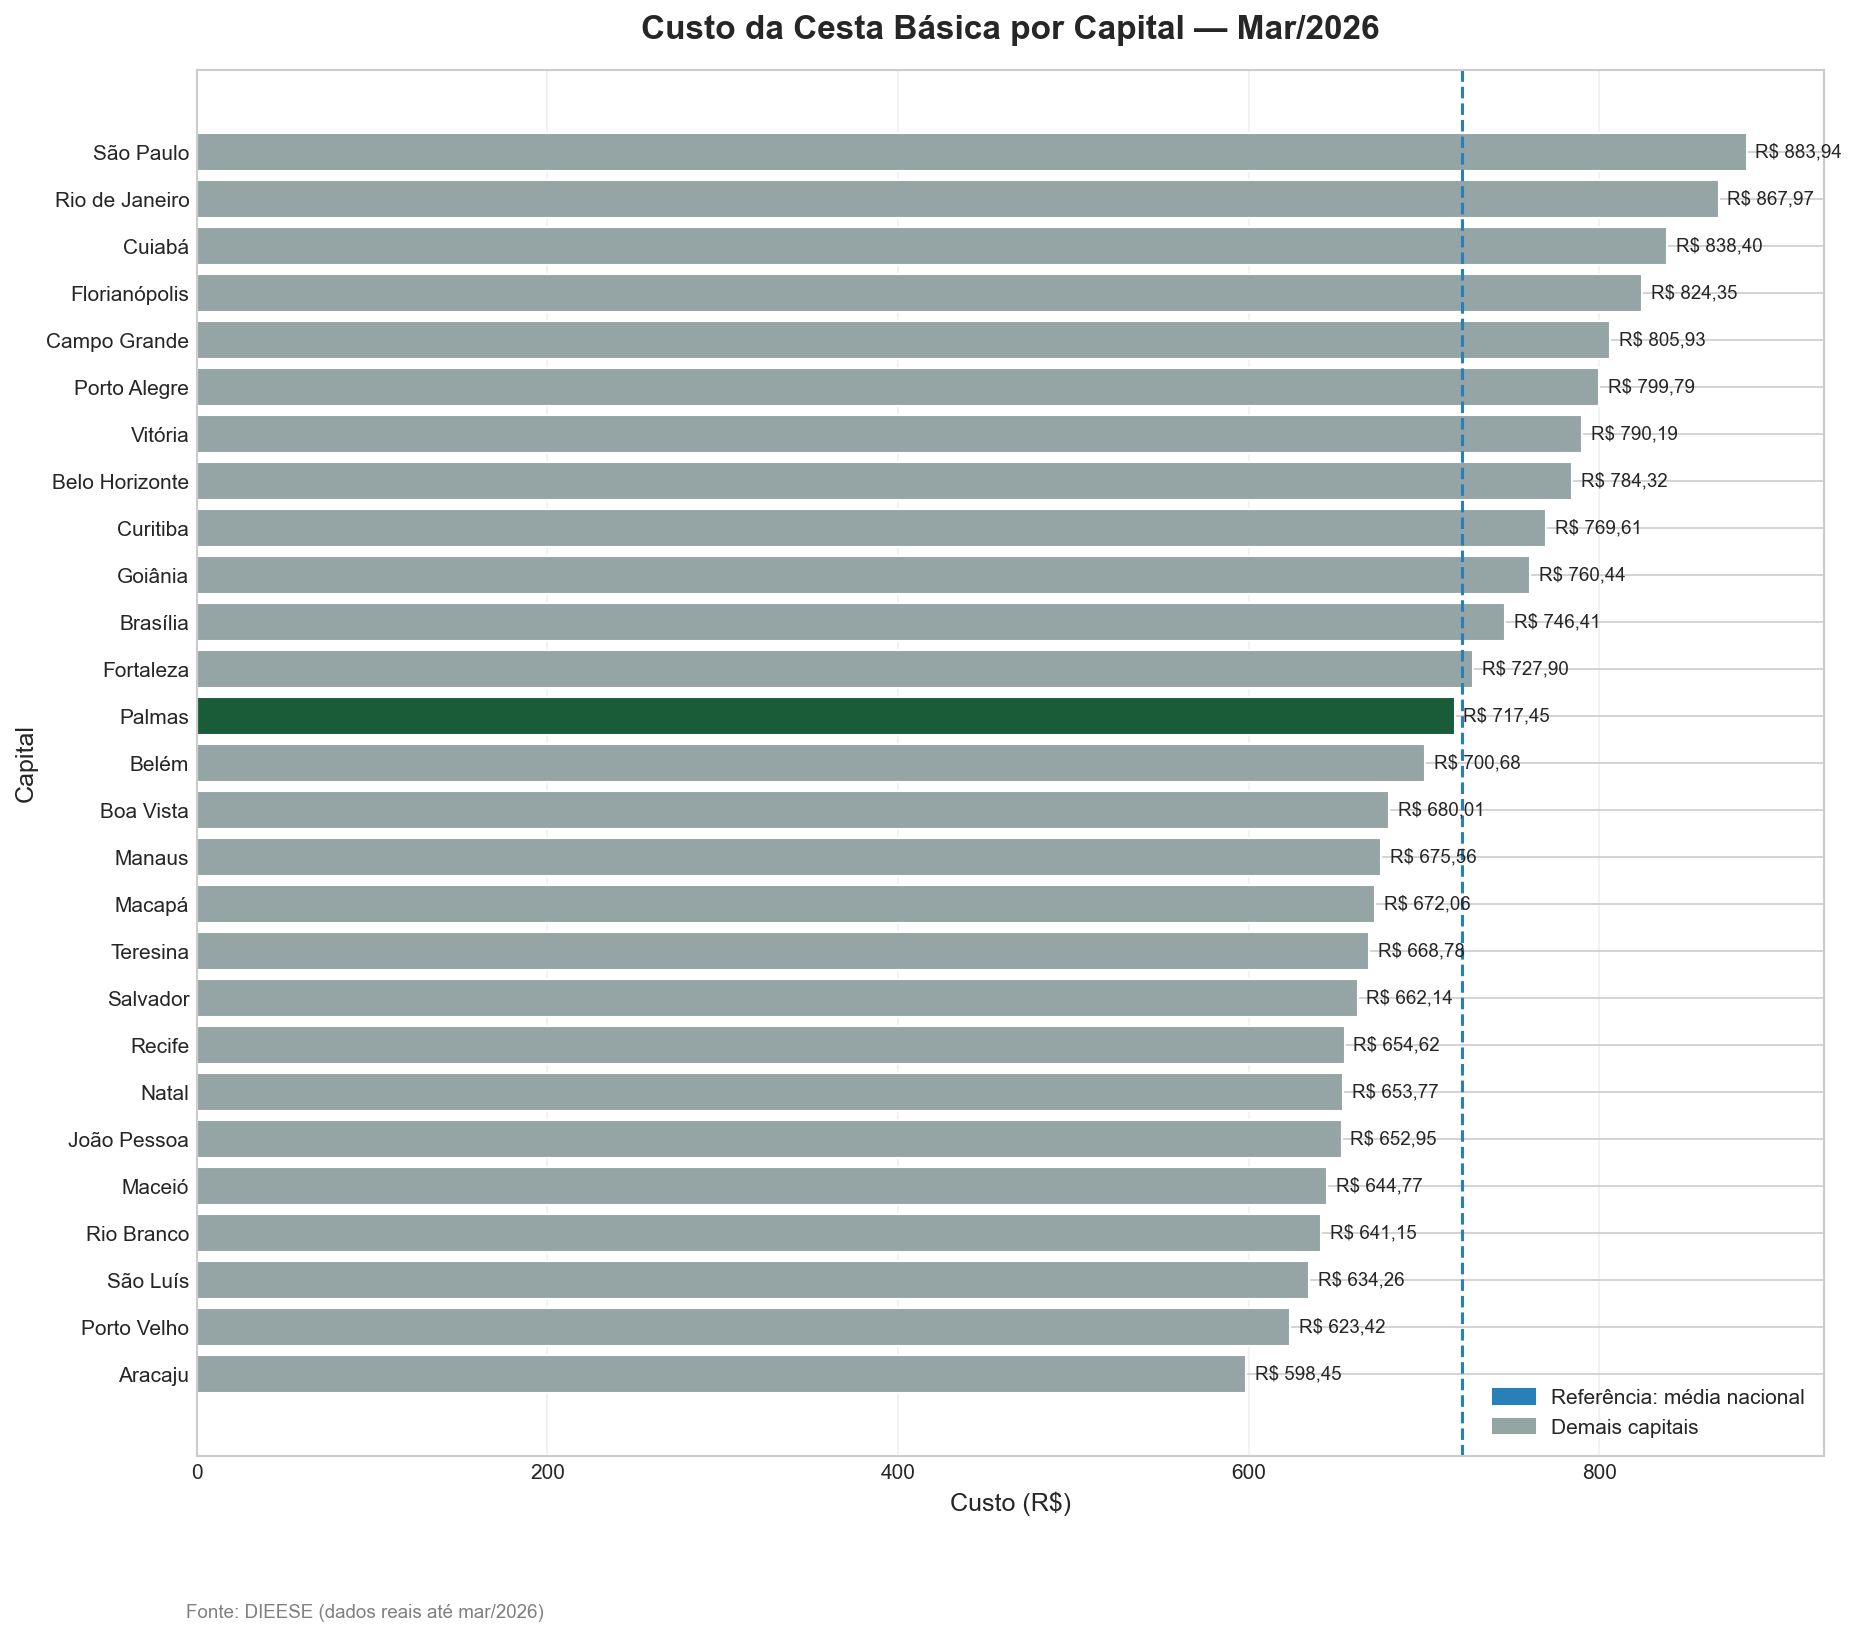

In [5]:
# Gerar todos os gráficos de EDA
caminhos_eda = executar_eda(df)

from IPython.display import Image, display
for nome, caminho in caminhos_eda.items():
    print(f"\n--- {nome} ---")
    display(Image(filename=str(caminho)))

### 3.2 Foco: Média Nacional

A média nacional agregada sintetiza a evolução do custo da cesta básica no país. A decomposição da série revela tendência de crescimento, sazonalidade anual (picos no início do ano) e resíduos compatíveis com ruído de mercado.

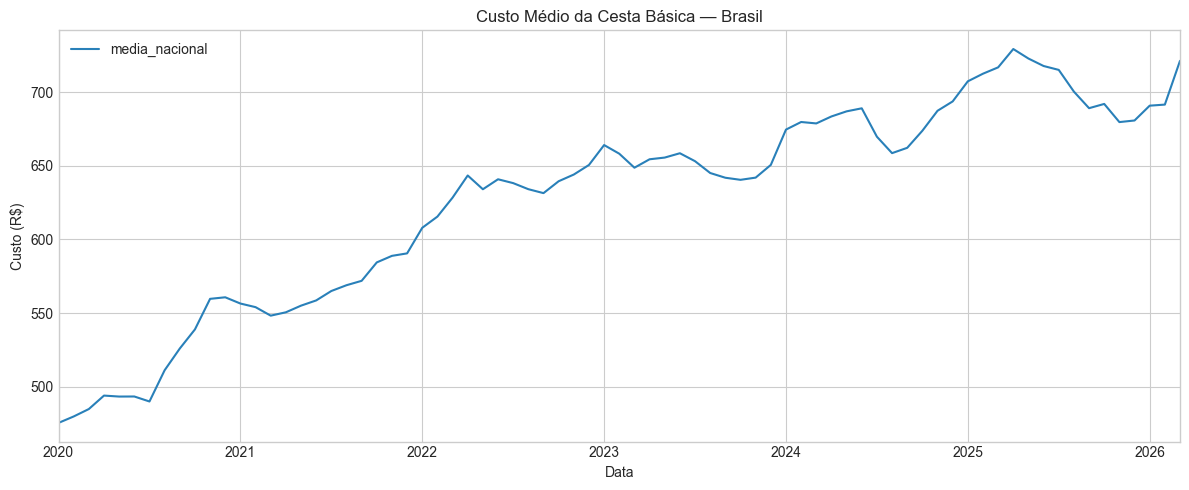

In [6]:
# Série da média nacional
serie_media = calcular_media_nacional(df)
serie_media.plot(x='data', y='media_nacional', figsize=(12, 5), title='Custo Médio da Cesta Básica — Brasil', color='#2980b9')
plt.ylabel('Custo (R$)')
plt.xlabel('Data')
plt.tight_layout()
plt.show()

### 3.3 Análise Regional

O boxplot regional evidencia que o **Sudeste** e o **Sul** concentram os maiores custos, enquanto o **Nordeste** e o **Norte** apresentam valores mais baixos. As capitais do Nordeste e do Norte tendem a apresentar custos abaixo da média nacional.

In [7]:
# Custo médio por região
df.groupby('regiao')['custo'].mean().sort_values(ascending=False).round(2)

regiao
Sul             703.03
Sudeste         694.34
Centro-Oeste    674.97
Norte           611.14
Nordeste        563.17
Name: custo, dtype: float64

## 4. 🤖 Modelagem Preditiva

Utilizamos dois modelos de séries temporais para prever o custo da cesta básica:

- **SARIMA** (Seasonal ARIMA): modelo estatístico clássico com busca automática de parâmetros via AIC
- **Prophet** (Facebook): modelo aditivo com sazonalidade anual/mensal e feriados brasileiros

**Período de treino:** Jan/2020 a Dez/2024  
**Período de teste:** Jan/2025 a Mar/2026

### 4.1 SARIMA

O SARIMA captura tendência e sazonalidade através de componentes autoregressivos e de médias móveis, com período sazonal de 12 meses.

### 4.2 Prophet

O Prophet decompõe a série em tendência, sazonalidades múltiplas e efeitos de feriados, sendo robusto a dados faltantes e mudanças de tendência.

### 4.3 Comparação de Métricas

Avaliamos os modelos com **MAE** (erro absoluto médio), **RMSE** (raiz do erro quadrático médio) e **MAPE** (erro percentual absoluto médio).

In [8]:
# Avaliar e exibir métricas
df_metricas = avaliar_modelos(df)
df_metricas


Avaliando modelos para: Média Nacional
  SARIMA(2,1,2)(1,1,0,12) — AIC: 226.35


00:05:03 - cmdstanpy - INFO - Chain [1] start processing
00:05:05 - cmdstanpy - INFO - Chain [1] done processing



Métricas salvas em: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\outputs\metricas_modelos.csv

MÉTRICAS DE AVALIAÇÃO
  Média Nacional | SARIMA | MAE: 15.5172
  Média Nacional | SARIMA | RMSE: 19.7367
  Média Nacional | SARIMA | MAPE: 2.2169
  Média Nacional | Prophet | MAE: 15.7777
  Média Nacional | Prophet | RMSE: 21.0953
  Média Nacional | Prophet | MAPE: 2.2621


,serie,modelo,metrica,valor
0,Média Nacional,SARIMA,MAE,15.5172
1,Média Nacional,SARIMA,RMSE,19.7367
2,Média Nacional,SARIMA,MAPE,2.2169
3,Média Nacional,Prophet,MAE,15.7777
4,Média Nacional,Prophet,RMSE,21.0953
5,Média Nacional,Prophet,MAPE,2.2621


In [9]:
# Tabela pivotada de métricas
df_metricas.pivot_table(index=['serie', 'modelo'], columns='metrica', values='valor').round(2)

metrica                   MAE  MAPE   RMSE
serie          modelo                     
Média Nacional Prophet  15.78  2.26  21.10
               SARIMA   15.52  2.22  19.74

## 5. 🔮 Projeções 2026–2030

Com base no modelo Prophet, projetamos o custo da cesta básica de **abril/2026 a dezembro/2030** em três cenários de inflação para alimentos:

| Cenário | Inflação Anual |
|---------|---------------|
| Otimista | 3,0% |
| Moderado | 4,5% |
| Conservador | 6,0% |

### 5.1 Média Nacional — Três Cenários

Este é o **gráfico principal** da apresentação. Mostra a trajetória histórica e as três projeções, com faixa de incerteza entre os cenários otimista e conservador.

In [10]:
# Executar modelagem completa (métricas + projeções + gráficos)
resultados = executar_modelagem(df)


Avaliando modelos para: Média Nacional


00:05:20 - cmdstanpy - INFO - Chain [1] start processing


  SARIMA(2,1,2)(1,1,0,12) — AIC: 226.35


00:05:22 - cmdstanpy - INFO - Chain [1] done processing



Métricas salvas em: D:\projetos start\Projeto_tcc\cesta-basica-pipeline\outputs\metricas_modelos.csv

MÉTRICAS DE AVALIAÇÃO
  Média Nacional | SARIMA | MAE: 15.5172
  Média Nacional | SARIMA | RMSE: 19.7367
  Média Nacional | SARIMA | MAPE: 2.2169
  Média Nacional | Prophet | MAE: 15.7777
  Média Nacional | Prophet | RMSE: 21.0953
  Média Nacional | Prophet | MAPE: 2.2621

Gerando projeções para: Aracaju

Gerando projeções para: Belo Horizonte

Gerando projeções para: Belém

Gerando projeções para: Boa Vista

Gerando projeções para: Brasília

Gerando projeções para: Campo Grande

Gerando projeções para: Cuiabá

Gerando projeções para: Curitiba

Gerando projeções para: Florianópolis

Gerando projeções para: Fortaleza

Gerando projeções para: Goiânia

Gerando projeções para: João Pessoa

Gerando projeções para: Macapá

Gerando projeções para: Maceió

Gerando projeções para: Manaus

Gerando projeções para: Natal

Gerando projeções para: Palmas

Gerando projeções para: Porto Alegre

Geran

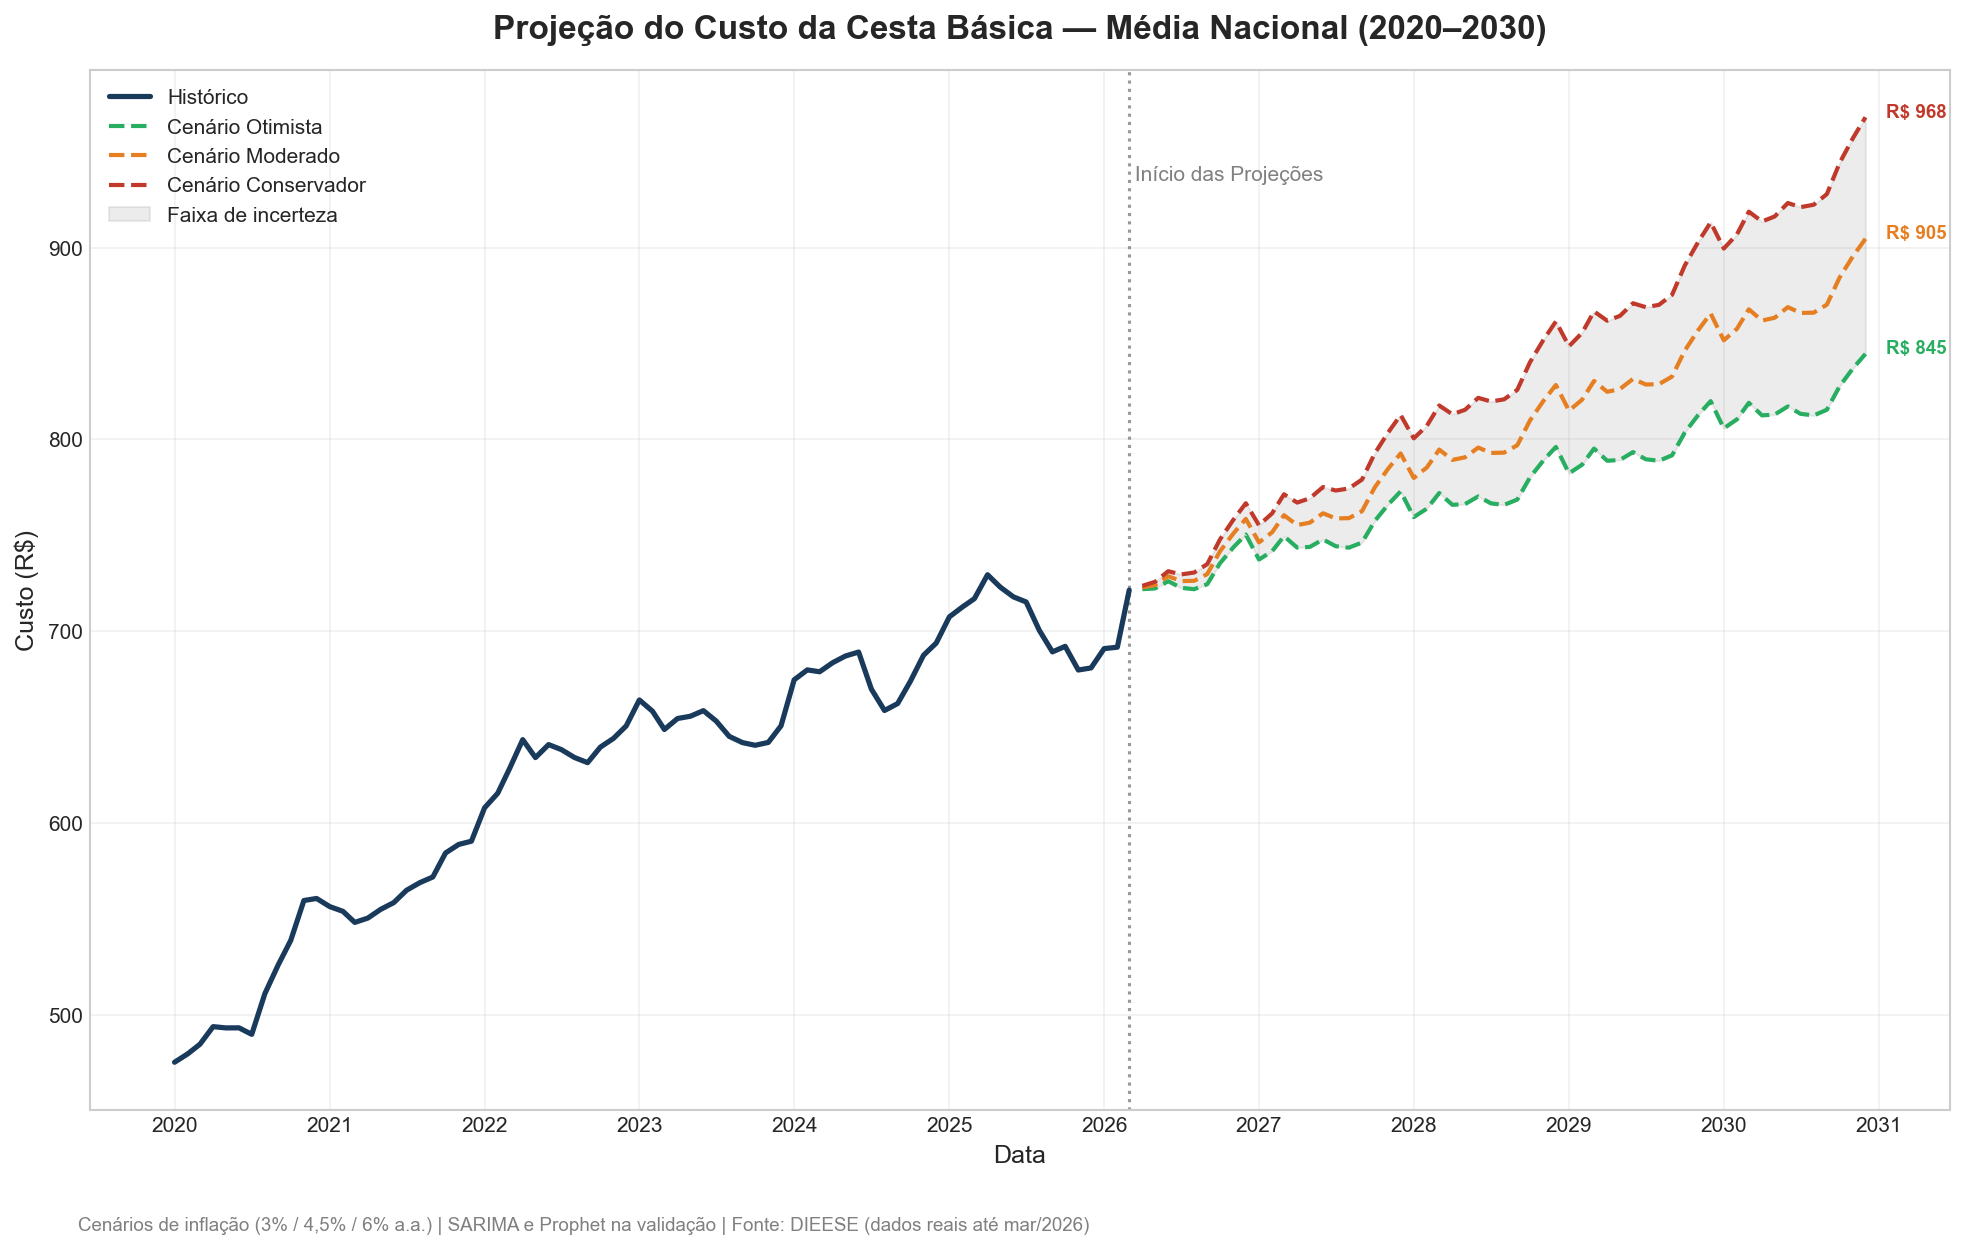

In [11]:
# Exibir gráfico principal — Média Nacional
from IPython.display import Image, display
display(Image(filename=str(PROJECT_ROOT / 'outputs' / 'graficos' / 'projecao_media_nacional_2020_2030.png')))

### 5.2 Projeção Nacional

A projeção da média nacional consolida a tendência agregada do país para o horizonte 2026–2030.

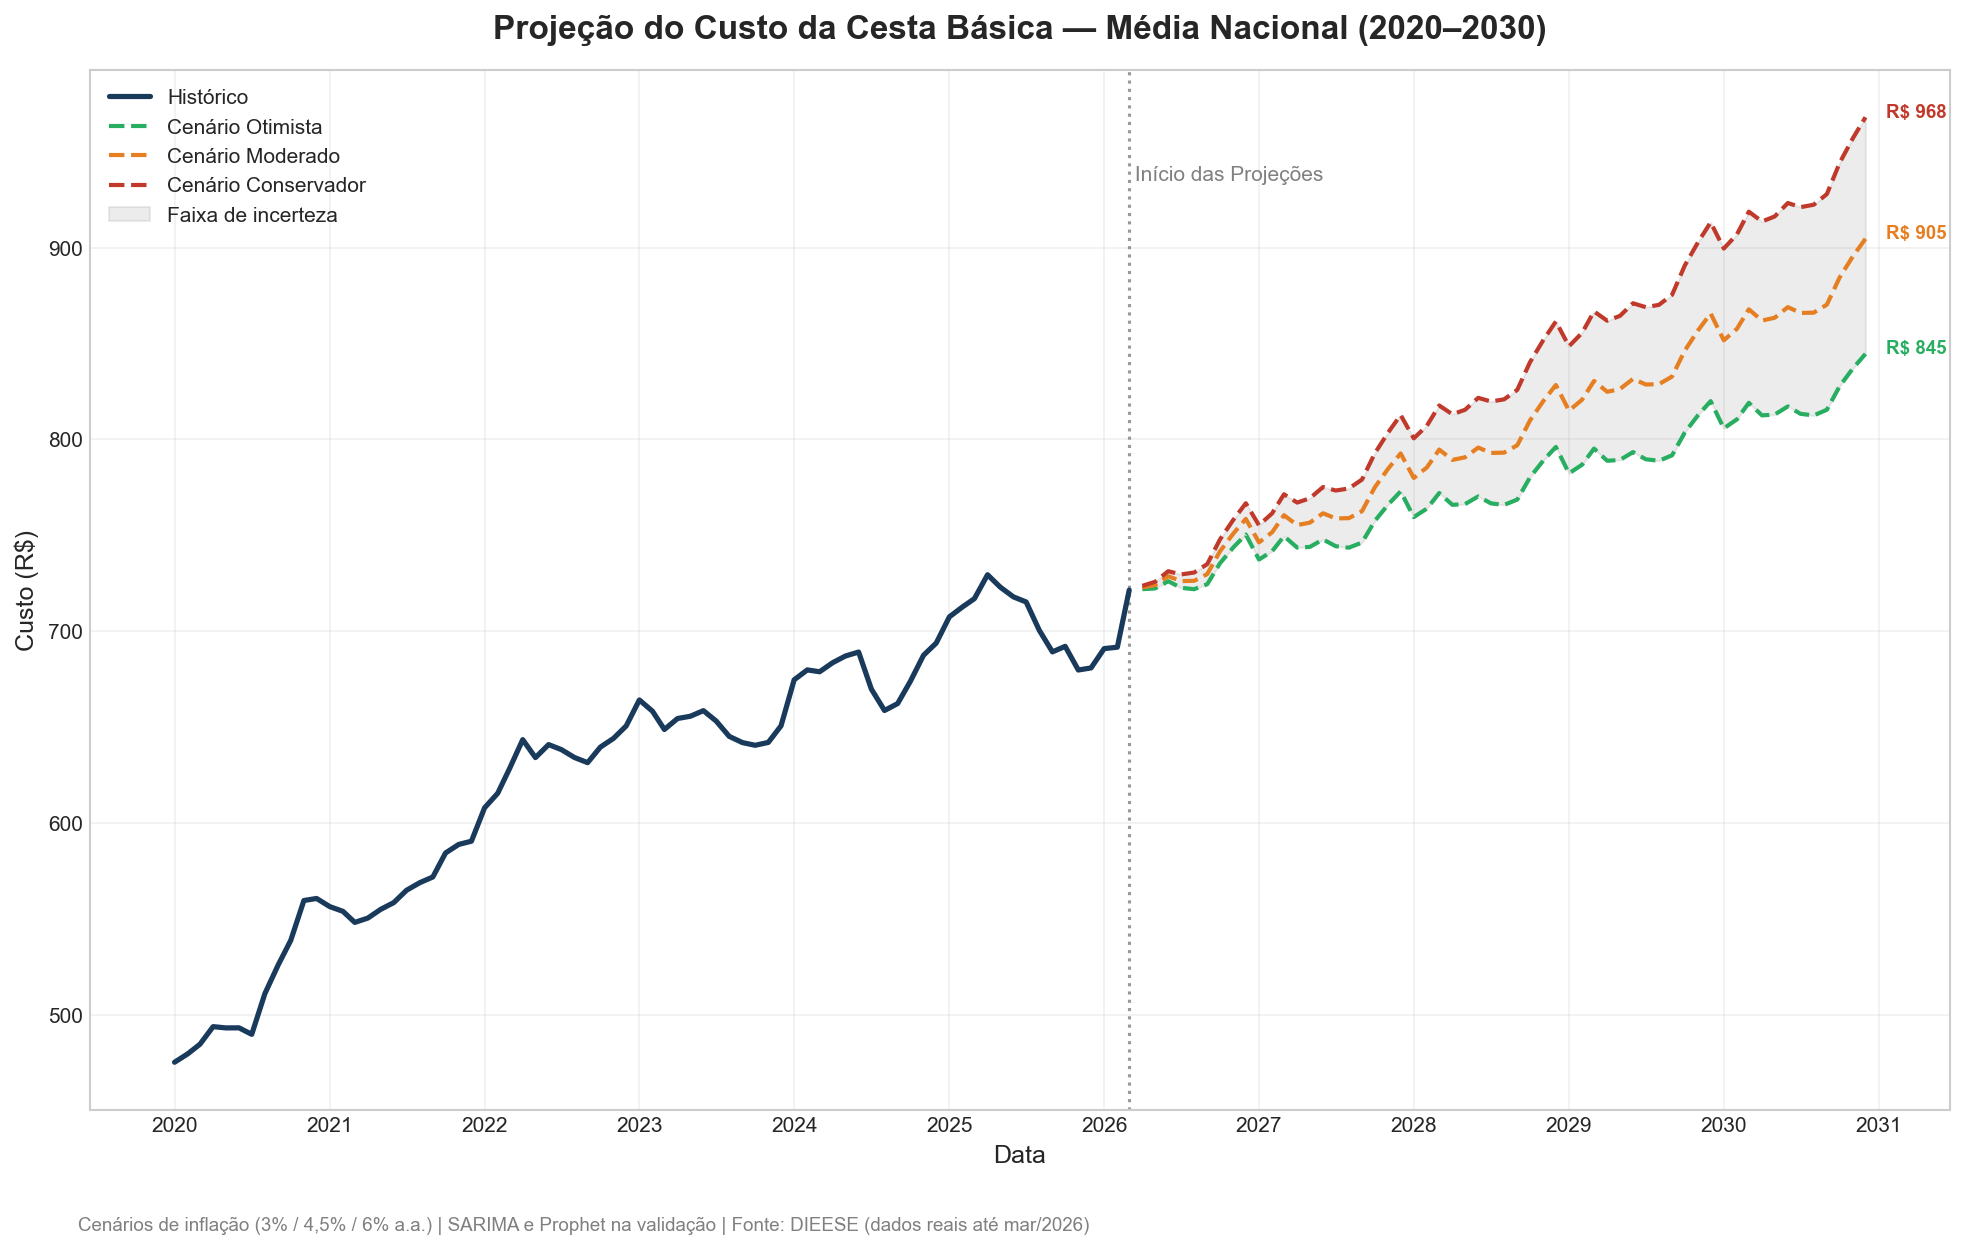

In [12]:
display(Image(filename=str(PROJECT_ROOT / 'outputs' / 'graficos' / 'projecao_media_nacional_2020_2030.png')))

In [13]:
# Valores projetados em dez/2030 por cenário — Média Nacional
proj_media = resultados['projecoes'][resultados['projecoes']['capital'] == 'Média Nacional']
dez2030 = proj_media[proj_media['data'] == '2030-12-01'][['cenario', 'custo_projetado']]
print("Projeção Média Nacional — Dez/2030:")
dez2030


Projeção Média Nacional — Dez/2030:


,cenario,custo_projetado
4673,Otimista,844.61
4730,Moderado,904.65
4787,Conservador,968.02


## 6. 📋 Conclusões

### Principais achados:

1. **Tendência de alta:** O custo da cesta básica apresentou crescimento consistente de 2020 a 2026, com aceleração no período da pandemia.
2. **Disparidade regional:** Capitais do Norte e Nordeste tendem a apresentar custos abaixo da média nacional, enquanto Sudeste e Sul concentram os maiores valores.
3. **Sazonalidade marcante:** Picos em janeiro-fevereiro e quedas em abril-maio são observados em todas as regiões.
4. **Projeções até 2030:** Mesmo no cenário otimista (3% a.a.), a média nacional deve superar R$ 850; no conservador (6% a.a.), pode ultrapassar R$ 950.
5. **Modelos complementares:** SARIMA e Prophet apresentam desempenho comparável no período de teste, validando as projeções.

### Arquivos gerados:

- `outputs/graficos/` — 7 PNGs para slides
- `outputs/metricas_modelos.csv` — métricas de avaliação
- `outputs/projecoes_2026_2030.csv` — projeções mensais por cenário
- `data/processed/` — dados processados (CSV + SQLite)

In [14]:
# Listar todos os arquivos gerados
print("=== Gráficos ===")
for f in sorted(OUTPUT_GRAFICOS.glob('*.png')):
    print(f"  {f.name}")

print("\n=== Outputs ===")
for f in sorted((PROJECT_ROOT / 'outputs').glob('*.csv')):
    print(f"  {f.name}")

=== Gráficos ===
  01_evolucao_historica_nacional.png
  02_heatmap_capitais.png
  03_decomposicao_media_nacional.png
  04_boxplot_regional.png
  05_ranking_capitais_marco2026.png
  projecao_media_nacional_2020_2030.png

=== Outputs ===
  metricas_modelos.csv
  projecoes_2026_2030.csv
